In [2]:
#General Packages
import pandas as pd
import torch
import torch.nn.functional as F
import ast
import scipy.stats as stats
import os

#Statistical tests
import statsmodels.formula.api as smf

#Plot
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

In [4]:
directory = '../hpc_result/'

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f)) for f in os.listdir(directory) if f.endswith('.csv')],
    ignore_index=True
).drop_duplicates()

In [5]:
nan_rows = df[df.isna().any(axis=1)]
df.loc[df['first_success_iter'].isna(), 'attack_successful'] = False
df['first_success_iter'] = df['first_success_iter'].fillna(1000000)

In [6]:
model_counts = df['model'].value_counts()
print(model_counts)

model
mobilenet_imagenet20_adv       11808
mobilenet_imagenet20           11808
mobilenet_imagenet20_robust    11808
resnet_imagenet20_adv          11808
resnet_imagenet20              11808
resnet_imagenet20_robust       11808
swin_imagenet20_adv            11808
swin_imagenet20                11808
swin_imagenet20_robust         11808
Name: count, dtype: int64


In [9]:
df_mobilenet = df[df['model'] == 'mobilenet_imagenet20_adv'].copy()
df_resnet    = df[df['model'] == 'resnet_imagenet20_adv'].copy()
df_swin      = df[df['model'] == 'swin_imagenet20_adv'].copy()

In [10]:
df_models = pd.concat([df_mobilenet, df_resnet, df_swin], ignore_index=True)

In [11]:
df_fgsm = df_models[df_models['attack'] == 'fgsm'].copy()
df_cw    = df_models[df_models['attack'] == 'cw'].copy()
df_pgd      = df_models[df_models['attack'] == 'pgd'].copy()

In [12]:
df_attack = pd.concat([df_fgsm, df_cw, df_pgd], ignore_index=True)

### Attacks general statistics

In [21]:
df_fgsm.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.465786,9.271680,9.148459,723919.572239,84.992763,0.999990,8.744351e+05,1994.761179
std,5.787412,5.769331,5.815465,5.789500,447071.995510,0.585076,0.000005,6.051482e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,84.221191,0.999975,5.722418e-01,0.000000
25%,5.000000,4.000000,4.000000,4.000000,37.000000,84.467386,0.999987,1.122624e+01,999.750000
50%,10.000000,9.000000,8.000000,8.000000,1000000.000000,84.748932,0.999990,1.098562e+06,1995.500000
75%,15.000000,14.000000,15.000000,15.000000,1000000.000000,85.652422,0.999996,1.347879e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,87.488281,0.999997,1.568424e+06,3991.000000


In [22]:
df_pgd.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.467649,9.271680,9.126694,795148.859925,87.070622,0.999993,7.017879e+05,1994.761179
std,5.787412,5.722557,5.815465,5.775467,403597.540941,1.629356,0.000004,5.025058e+05,1151.774203
min,0.000000,0.000000,0.000000,0.000000,0.000000,85.093346,0.999982,2.839196e-01,0.000000
25%,5.000000,5.000000,4.000000,4.000000,1000000.000000,85.775520,0.999991,9.092031e+00,999.750000
50%,10.000000,9.000000,8.000000,8.000000,1000000.000000,86.179955,0.999992,7.927817e+05,1995.500000
75%,15.000000,14.000000,15.000000,15.000000,1000000.000000,88.572622,0.999998,1.091339e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,93.652077,0.999999,1.395949e+06,3991.000000


In [23]:
df_cw.describe()


,true_class,target_class,original_pred_class,adversarial_pred_class,first_success_iter,psnr_score,ssim_score,ergas_score,dataset_index
count,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,11808.000000,1.180800e+04,11808.000000
mean,9.532774,9.465871,9.271680,9.097561,529728.935976,85.220005,0.999922,2.071774e+06,1994.761179
std,5.787412,5.737092,5.815465,5.790735,499133.211632,16.711503,0.000089,2.277176e+06,1151.774203
min,0.000000,0.000000,0.000000,0.000000,1.000000,68.528976,0.999485,3.440880e-03,0.000000
25%,5.000000,5.000000,4.000000,4.000000,5.000000,73.614361,0.999892,2.871142e+01,999.750000
50%,10.000000,9.000000,8.000000,8.000000,1000000.000000,75.580387,0.999946,7.516096e+05,1995.500000
75%,15.000000,14.000000,15.000000,14.000000,1000000.000000,98.630831,1.000000,4.114895e+06,2991.250000
max,19.000000,19.000000,19.000000,19.000000,1000000.000000,131.553650,1.000000,9.121141e+06,3991.000000


In [24]:
df_attack = df_attack[df_attack["first_success_iter"] != 1000000]
df_attack.groupby('attack')['first_success_iter'].mean()

attack
cw       7.072934
fgsm    12.978221
pgd     48.672179
Name: first_success_iter, dtype: float64

# Successrate

In [ ]:
# Calculate success rates
success_rates = df_mobilenet.groupby('attack')['attack_successful'].mean()
counts = df_mobilenet.groupby('attack')['attack_successful'].sum()
totals = df_mobilenet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals (normal approximation or use 'wilson')
ci_df_mobilenet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_mobilenet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_mobilenet)

      success_rate       n    ci_low   ci_high
cw        0.023120  3936.0  0.018425  0.027815
fgsm      0.023882  3936.0  0.019112  0.028652
pgd       0.021341  3936.0  0.016827  0.025856


In [27]:
# Calculate success rates
success_rates = df_resnet.groupby('attack')['attack_successful'].mean()
counts = df_resnet.groupby('attack')['attack_successful'].sum()
totals = df_resnet.groupby('attack')['attack_successful'].count()

# Compute confidence intervals (normal approximation or use 'wilson')
ci_df_resnet = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')  
    ci_df_resnet.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_resnet)

      success_rate       n    ci_low   ci_high
cw        0.265244  3936.0  0.251452  0.279036
fgsm      0.540904  3936.0  0.525336  0.556472
pgd       0.529726  3936.0  0.514133  0.545318


In [28]:
# Calculate success rates
success_rates = df_swin.groupby('attack')['attack_successful'].mean()
counts = df_swin.groupby('attack')['attack_successful'].sum()
totals = df_swin.groupby('attack')['attack_successful'].count()

# Compute confidence intervals (normal approximation or use 'wilson')
ci_df_swin = pd.DataFrame(columns=["success_rate", "n", "ci_low", "ci_high"])

for attack in success_rates.index:
    x = counts[attack]
    n = totals[attack]
    rate = success_rates[attack]
    ci_low, ci_high = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal') 
    ci_df_swin.loc[attack] = [rate, n, ci_low, ci_high]

# Display the result
print(ci_df_swin)

      success_rate       n    ci_low   ci_high
cw        0.000000  3936.0  0.000000  0.000000
fgsm      0.065041  3936.0  0.057337  0.072745
pgd       0.061230  3936.0  0.053740  0.068720


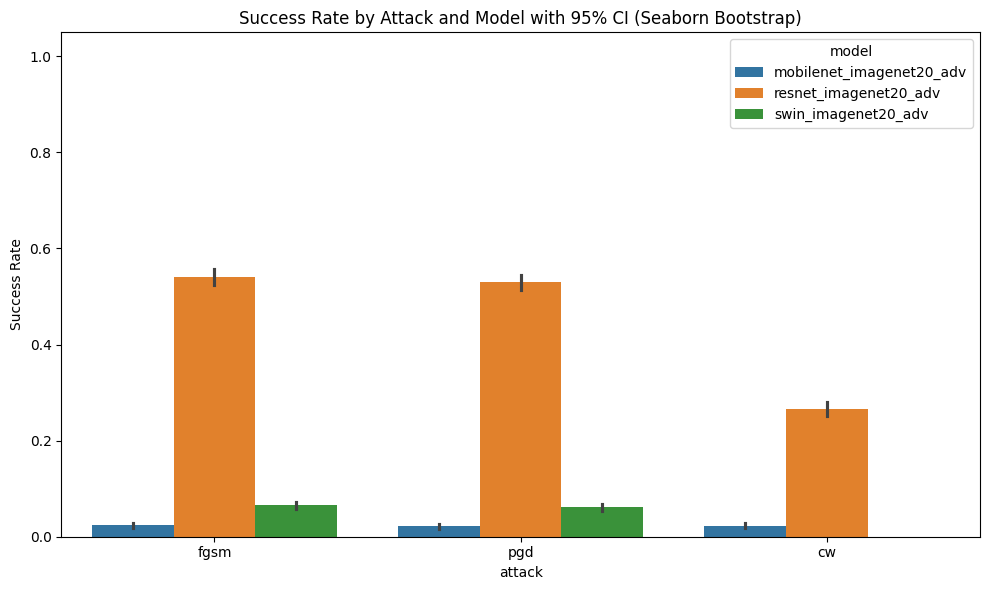

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_models,
    x="attack",
    y="attack_successful",
    hue="model",
    errorbar=('ci', 95),
    estimator=lambda x: x.mean() 
)

plt.title("Success Rate by Attack and Model with 95% CI (Seaborn Bootstrap)")
plt.ylabel("Success Rate")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
